<a href="https://colab.research.google.com/github/chandraniraychowdhury5/DS/blob/main/RenewableEnergy_part3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import scipy

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/datasetAndProgram/raw_renewable_energy_dataset.csv')
print(df.head())
print(df.info())
print(df.columns)

     Country  Year Energy Type  Production (GWh)  Installed Capacity (MW)  \
0        USA  2011       Solar      85404.690027              5549.794323   
1  Australia  2008  Geothermal      22205.069382             43211.593798   
2     Canada  2013     Biomass      94102.732038              6139.117212   
3      Japan  2010     Biomass      88771.932910             40323.639260   
4      China  2018       Solar      93288.408581             30755.403056   

   Investments (USD)  Population           GDP  Energy Consumption  \
0       5.604125e+09  1064007213  1.775278e+14       369654.644184   
1       6.361886e+08  1033255852  6.435372e+13       771781.636293   
2       6.158680e+09    14895124  1.567926e+14       342707.152899   
3       8.526116e+09  1448827283  1.350464e+14       498839.574253   
4       5.086237e+09  1499494307  8.677956e+13       819064.362785   

   Energy Exports  ...  Economic Freedom Index  Ease of Doing Business  \
0    93087.198199  ...               49.21

DATA CLEANING

In [ ]:
#missing values
print(df.isnull().sum())
#filled missing value with mean
df.fillna(df.mean(numeric_only=True), inplace = True)
#duplicates data
print(df.duplicated().sum())
#drop duplicates
df.drop_duplicates(inplace = True)
df.to_csv('/content/drive/MyDrive/datasetAndProgram/clean_renewable_energy_dataset.csv', index = False)


Country                                    0
Year                                       0
Energy Type                                0
Production (GWh)                           0
Installed Capacity (MW)                    0
Investments (USD)                          0
Population                                 0
GDP                                        0
Energy Consumption                         0
Energy Exports                             0
Energy Imports                             0
CO2 Emissions                              0
Renewable Energy Jobs                      0
Government Policies                        0
R&D Expenditure                            0
Renewable Energy Targets                   0
Average Annual Temperature                 0
Annual Rainfall                            0
Solar Irradiance                           0
Wind Speed                                 0
Hydro Potential                            0
Geothermal Potential                       0
Biomass Av

In [ ]:
df_clean = pd.read_csv('/content/drive/MyDrive/datasetAndProgram/clean_renewable_energy_dataset.csv')
print(df_clean.head())

     Country  Year Energy Type  Production (GWh)  Installed Capacity (MW)  \
0        USA  2011       Solar      85404.690027              5549.794323   
1  Australia  2008  Geothermal      22205.069382             43211.593798   
2     Canada  2013     Biomass      94102.732038              6139.117212   
3      Japan  2010     Biomass      88771.932910             40323.639260   
4      China  2018       Solar      93288.408581             30755.403056   

   Investments (USD)  Population           GDP  Energy Consumption  \
0       5.604125e+09  1064007213  1.775278e+14       369654.644184   
1       6.361886e+08  1033255852  6.435372e+13       771781.636293   
2       6.158680e+09    14895124  1.567926e+14       342707.152899   
3       8.526116e+09  1448827283  1.350464e+14       498839.574253   
4       5.086237e+09  1499494307  8.677956e+13       819064.362785   

   Energy Exports  ...  Economic Freedom Index  Ease of Doing Business  \
0    93087.198199  ...               49.21

Descriptive Statistics

In [ ]:
df_clean.describe()

,Year,Production (GWh),Installed Capacity (MW),Investments (USD),Population,GDP,Energy Consumption,Energy Exports,Energy Imports,CO2 Emissions,...,Economic Freedom Index,Ease of Doing Business,Innovation Index,Number of Research Institutions,Number of Renewable Energy Conferences,Number of Renewable Energy Publications,Energy Sector Workforce,Proportion of Energy from Renewables,Public-Private Partnerships in Energy,Regional Renewable Energy Cooperation
count,2500.000000,2500.000000,2500.000000,2.500000e+03,2.500000e+03,2.500000e+03,2500.000000,2500.000000,2500.000000,2500.000000,...,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.00000,2500.000000,2500.000000,2500.000000,2500.000000
mean,2011.437600,48743.195073,24882.910674,4.956155e+09,7.458927e+08,1.010745e+14,495701.245158,50143.392627,50800.373871,491218.412643,...,50.736720,48.442085,50.280019,496.660400,50.431200,4978.93360,502040.891200,49.749110,0.512000,0.473600
std,6.895471,28340.915147,14463.459958,2.894789e+09,4.373146e+08,5.782363e+13,291419.017957,28833.333066,28740.851763,289783.733338,...,28.623766,28.798216,28.719483,296.181011,28.877168,2881.93256,293084.636148,28.924307,0.499956,0.499402
min,2000.000000,1053.354158,114.531639,5.886994e+06,1.255357e+06,5.603965e+10,1264.851083,1036.618008,1057.783513,1124.768458,...,0.104915,0.025281,0.025733,0.000000,0.000000,3.00000,494.000000,0.033829,0.000000,0.000000
25%,2006.000000,24309.656479,12282.213159,2.473145e+09,3.720811e+08,5.049265e+13,237300.546551,25146.745295,26347.461047,242894.720511,...,26.241437,23.519814,25.934406,234.000000,26.000000,2532.00000,244438.000000,23.968451,0.000000,0.000000
50%,2011.000000,47367.117600,24689.162460,4.961772e+09,7.515190e+08,1.027006e+14,496118.165272,49706.656938,50698.800022,475721.007886,...,50.850766,48.127673,51.398964,493.000000,51.000000,4992.50000,499151.000000,50.232069,1.000000,0.000000
75%,2017.250000,73079.452832,37438.443570,7.418384e+09,1.118019e+09,1.519604e+14,753779.282813,75567.191515,75807.642495,747649.446362,...,74.908485,73.324825,74.724073,755.000000,76.000000,7465.00000,765088.000000,74.354781,1.000000,1.000000
max,2023.000000,99937.503719,49997.387577,9.998292e+09,1.499494e+09,1.999223e+14,999618.512172,99952.509817,99912.213813,999816.500175,...,99.970526,99.901347,99.998838,999.000000,99.000000,9999.00000,999226.000000,99.988355,1.000000,1.000000


In [ ]:
#India statistics
df_india = df[df['Country'] == 'India']
df_india = df_india[[
    'Year',
    'Energy Type',
    'Production (GWh)',
    'Installed Capacity (MW)',
    'Proportion of Energy from Renewables',
    'Solar Irradiance',
    'Wind Speed',
    'Hydro Potential',
    'Geothermal Potential',
    'Biomass Availability',
    'Average Annual Temperature',
    'Annual Rainfall',
    'Energy Storage Capacity',
    'Grid Integration Capability'
]]

df_india.describe()
# df_india.head(5)

,Year,Production (GWh),Installed Capacity (MW),Proportion of Energy from Renewables,Solar Irradiance,Wind Speed,Hydro Potential,Geothermal Potential,Biomass Availability,Average Annual Temperature,Annual Rainfall,Energy Storage Capacity,Grid Integration Capability
count,249.000000,249.000000,249.000000,249.000000,249.000000,249.000000,249.000000,249.000000,249.000000,249.000000,249.000000,249.000000,249.000000
mean,2012.108434,49553.173445,26075.528555,49.626270,196.696934,7.614406,49.217748,53.400476,50.117418,14.982112,1611.320347,535.074833,0.482885
std,6.500022,29178.818512,14162.084433,29.462056,57.953344,4.274056,30.088528,30.759801,29.403623,14.429674,848.362793,274.859165,0.286047
min,2000.000000,1053.354158,1017.167130,0.339346,100.946585,0.050978,0.385271,0.352350,0.024802,-9.546147,101.082742,1.157294,0.001835
25%,2007.000000,23892.450225,13912.820126,25.827003,145.413011,4.088354,21.097557,25.100679,26.521972,2.639817,906.061267,313.440312,0.247034
50%,2012.000000,47012.861272,26668.435813,49.761887,195.024337,7.825026,46.408801,55.624737,48.346120,14.998512,1617.916570,555.037281,0.464206
75%,2018.000000,75237.227333,39250.936469,75.452314,245.482325,11.406504,76.060154,81.991956,75.893183,27.588169,2344.561628,764.082199,0.725406
max,2023.000000,99696.606403,49938.844619,99.044414,299.510887,14.875122,99.219877,99.652792,99.484877,39.900547,2997.513760,999.317268,0.997448


In [ ]:
mean = df_india.mean(numeric_only= True)
median = df_india.median(numeric_only=True)
std = df_india.std(numeric_only=True)
var = df_india.var(numeric_only = True)
print("Mean:\n", mean)
print("Median:\n", median)
print("Standard Deviation:\n", std)
print("Variance:\n", var)


Mean:
 Year                                     2012.108434
Production (GWh)                        49553.173445
Installed Capacity (MW)                 26075.528555
Proportion of Energy from Renewables       49.626270
Solar Irradiance                          196.696934
Wind Speed                                  7.614406
Hydro Potential                            49.217748
Geothermal Potential                       53.400476
Biomass Availability                       50.117418
Average Annual Temperature                 14.982112
Annual Rainfall                          1611.320347
Energy Storage Capacity                   535.074833
Grid Integration Capability                 0.482885
dtype: float64
Median:
 Year                                     2012.000000
Production (GWh)                        47012.861272
Installed Capacity (MW)                 26668.435813
Proportion of Energy from Renewables       49.761887
Solar Irradiance                          195.024337
Wind Speed     

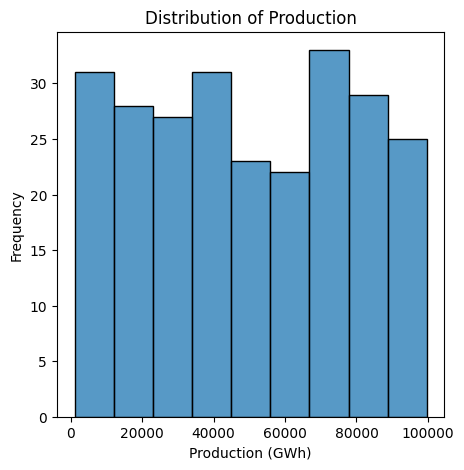

In [ ]:
# Visualization
plt.figure(figsize = (5, 5))
sns.histplot(x = df_india['Production (GWh)'])
plt.xlabel('Production (GWh)')
plt.ylabel('Frequency')
plt.title('Distribution of Production')
plt.show()

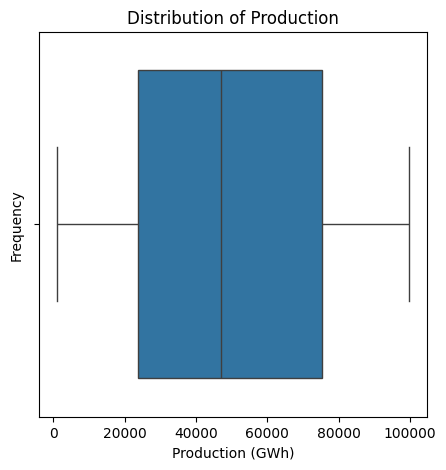

count      249.000000
mean     49553.173445
std      29178.818512
min       1053.354158
25%      23892.450225
50%      47012.861272
75%      75237.227333
max      99696.606403
Name: Production (GWh), dtype: float64


In [ ]:
plt.figure(figsize = (5, 5))
sns.boxplot(x = df_india['Production (GWh)'])
plt.xlabel('Production (GWh)')
plt.ylabel('Frequency')
plt.title('Distribution of Production')
plt.show()

print(df_india['Production (GWh)'].describe())

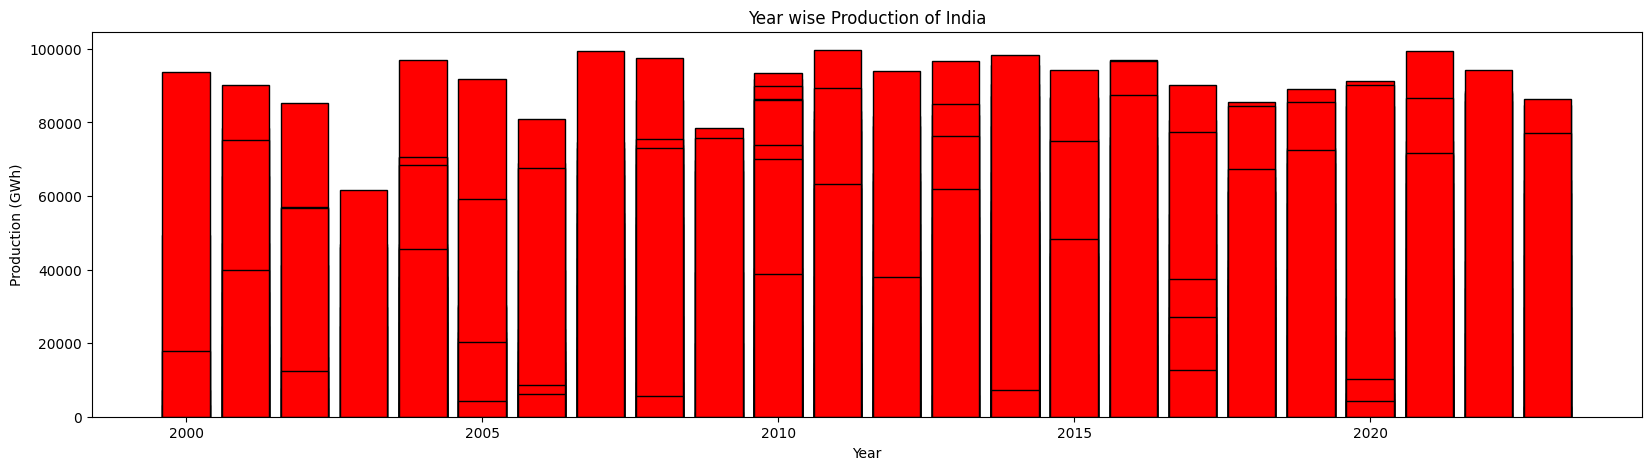

In [ ]:
plt.figure(figsize = (20, 5))
x = df_india['Year']
y = df_india['Production (GWh)']
plt.bar(x, y, color = 'red', edgecolor = 'black')
plt.ylabel('Production (GWh)')
plt.xlabel('Year')
plt.title('Year wise Production of India')
plt.show()


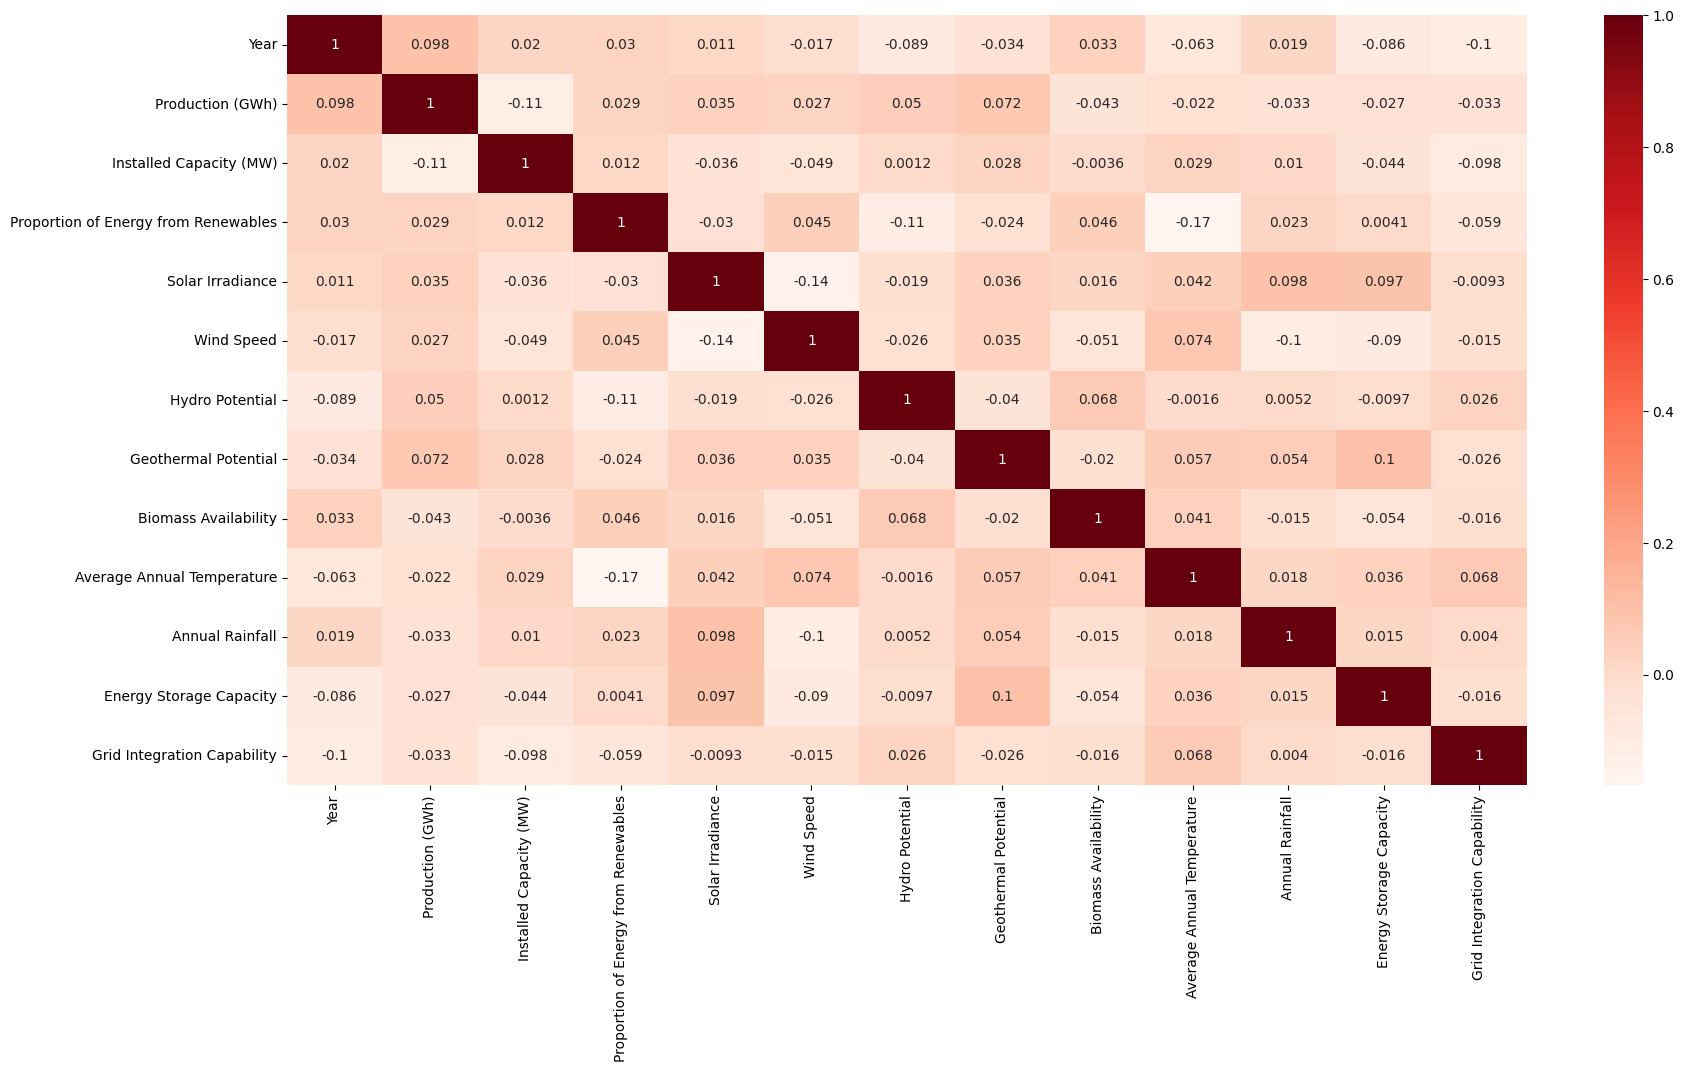

In [ ]:
plt.figure(figsize = (20, 10))
cor = df_india.corr(numeric_only = True)
# print(cor)
sns.heatmap(cor, annot = True, cmap = plt.cm.Reds)
plt.plot()
plt.show()


Inferential Statistics

One-Sample t-Test
Hypothesis
Determine whether the mean production of a particular energy type differs from a benchmark value.
Example:
H0 : Mean Solar production = 5000 GWh
H1 : Mean Solar production ≠ 5000 GWh

In [ ]:
from scipy import stats

solar = df_india[df_india['Energy Type'] == 'Solar']['Production (GWh)']
tstat, pvalue = stats.ttest_1samp(solar, popmean= 5000)
print('t-statistic:', tstat)
print('p-value:', pvalue)

#Decision
# t-statistic: 9.969303418700171
# p-value: 4.988865593285651e-12
# Since p < 0.05, reject H0.
# Conclusion: The average production is significantly different from the benchmark value used in the test.


t-statistic: 9.969303418700171
p-value: 4.988865593285651e-12


Independent Two-Sample t-Test
Hypothesis
Compare mean production between two energy types.
Example:H0 : Mean Solar production = Mean Wind production
H1 : Means are different

In [ ]:
from scipy import stats

solar = df_india[df_india['Energy Type'] == 'Solar']['Production (GWh)']
wind = df_india[df_india['Energy Type'] == 'Wind']['Production (GWh)']
tstat, pvalue = stats.ttest_ind(solar, wind, equal_var= False)
print('t-statistic:', tstat)
print('p-value:', pvalue)

# t-statistic: 0.011645532435746335
# p-value: 0.9907390496073831
# The p-value (0.9907) is much larger than the common significance level of 0.05.
# Since:
                          # p=0.9907>0.05 -- fail to reject the null hypothesis.
# Conclusion
# There is no statistically significant difference between the mean production values of the two energy types being compared.


t-statistic: 0.011645532435746335
p-value: 0.9907390496073831


One-Way ANOVA

Hypothesis

Test whether average production differs among all energy types.

H0 : All energy types have the same mean production

H1 : At least one mean differs

In [ ]:
from scipy.stats import f_oneway

biomass = df_india[df_india['Energy Type']=='Biomass']['Production (GWh)']
geo = df_india[df_india['Energy Type']=='Geothermal']['Production (GWh)']
hydro = df_india[df_india['Energy Type']=='Hydro']['Production (GWh)']
solar = df_india[df_india['Energy Type']=='Solar']['Production (GWh)']
wind = df_india[df_india['Energy Type']=='Wind']['Production (GWh)']
fstat, pvalue = f_oneway(biomass, geo, hydro, solar, wind)
print('F-statistic:', fstat)
print('p-value:', pvalue)

# The p-value is: 0.7235650798228652
# 0.7235650798228652 > 0.05
# the result is not statistically significant.

# Decision
# Fail to reject the null hypothesis (H0).

# Conclusion
# There is no statistically significant evidence that the average production differs among the five energy types.


F-statistic: 0.5166490136995041
p-value: 0.7235650798228652


Two-Way ANOVA
Useful because your data has:
• Energy Type
• Year
Hypothesis
Factor 1: Energy Type affects production
Factor 2: Year affects production
Interaction: Energy Type x Year affects production

In [ ]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

model = ols(
    'Q("Production (GWh)") ~ C(Q("Energy Type")) + C(Year) + C(Q("Energy Type")):C(Year)',
    data=df_india
).fit()

anova_table = sm.stats.anova_lm(model, typ=2)

print(anova_table)

#  Source              Fvalue  pvalue (PR(>F))  Interpretation

#  Energy Type         0.373    0.772             Not significant
#  Year                1.478    0.132             Not significant
#  Energy Type x Year  0.858    0.775             Not significant


# Using the common significance level of alpha = 0.05:

# Energy Type: p = 0.772 > 0.05: No statistically significant difference among energy types.

# Year: p = 0.132 > 0.05: No statistically significant change across years.

# Interaction: p = 0.775 > 0.05: The effect of energy type does not significantly depend on year.

# Conclusion
# The ANOVA provides no evidence that the production differs significantly by energy type, by year, or by the combination of energy type and year.

                                   sum_sq     df         F    PR(>F)
C(Q("Energy Type"))          1.352403e+09    4.0  0.373271  0.772407
C(Year)                      3.080081e+10   23.0  1.478469  0.132027
C(Q("Energy Type")):C(Year)  7.153477e+10   92.0  0.858435  0.775021
Residual                     1.313379e+11  145.0       NaN       NaN


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 4, but rank is 3
  warnings.warn('covariance of constraints does not have full '
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 23, but rank is 13
  warnings.warn('covariance of constraints does not have full '
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 92, but rank is 82
  warnings.warn('covariance of constraints does not have full '


Chi-Square Test of Independence

Chi-square requires categorical variables.

Since Production is continuous, first convert it into categories.

Hypothesis

H0 : Energy Type and Production Level are independent

H1 : They are associated

In [ ]:
df_india['Production Category'] = pd.cut(
    df_india['Production (GWh)'],
    bins = 3,
    labels = ["low", "medium", "high"])

df_india['Production Category']

,Production Category
5,high
16,high
21,low
30,high
58,high
...,...
2407,medium
2441,medium
2453,high
2466,high


In [ ]:
from scipy.stats import chi2_contingency

Ctable = pd.crosstab(df_india['Energy Type'], df_india['Production Category'])

chi2, pvalue, dof, expected = chi2_contingency(Ctable)

print('Chi-square statistic:', chi2)

print('p-value:', pvalue)


# Decision

# Using a significance level of alpha = 0.05:

# p-value = 0.9187 > 0.05

# Therefore, fail to reject H0.

# Conclusion

# There is no statistically significant evidence of an association between Energy Type and Production Level.

Chi-square statistic: 3.235208869993634
p-value: 0.918741491862118


F-Statistic for Variance Comparison

Compare variability between two energy types.

H0 : Variances are equal

In [ ]:
from scipy.stats import f

solar = df_india[df_india['Energy Type'] == 'Solar']['Production (GWh)']
wind = df_india[df_india['Energy Type'] == 'Wind']['Production (GWh)']
var1 = np.var(solar, ddof = 1)
var2 = np.var(wind, ddof = 1)
fstat = var1 / var2
dfsolar = len(solar) - 1
dfwind = len(wind) - 1
pvalue = 2 * min(f.cdf(fstat, dfsolar, dfwind), 1 - f.cdf(fstat, dfsolar, dfwind))

print('F-statistic:', fstat)

print('p-value:', pvalue)

# Decision

# Using alpha = 0.05:

# p-value = 0.9722 > 0.05

# Therefore, fail to reject H0.

# Conclusion

# There is no statistically significant evidence that the variances differ between the two energy types. ]

# The production levels for the two energy types exhibit similar variability.


F-statistic: 0.9813165938664655
p-value: 0.9722070739741067


Trend Analysis Over Years (Regression)

Hypothesis

H0 : Production does not change with Year

H1 : Production changes with Year

In [ ]:
from scipy.stats import linregress

solar = df_india[df_india['Energy Type'] == 'Solar']
x = solar['Year']
y = solar['Production (GWh)']
slope, intercept, rvalue, pvalue, stderr = linregress(x, y)
print('Slope:', slope)
print('p-value:', pvalue)
print('rvalue', rvalue**2)
print('error', stderr)


# Results
# Slope = 1123.46
# p-value = 0.1693
# Correlation coefficient (r) = 0.0518
# Standard error of slope = 800.89

# Decision

# Using alpha = 0.05:

# p-value = 0.1693 > 0.05
# Therefore, fail to reject H0.

# Interpretation
# Though the estimated slope is positive (1123.46), suggesting production increases by about 1,123 units per year on average,
# this trend is not statistically significant.

# The correlation coefficient:
# r = 0.0518 : indicates an extremely weak positive relationship between Year and Production.

# The coefficient of determination is:
# rsquare =(0.0518)^2 = 0.0027

# This means that only about 0.27% of the variation in production is explained by year, which is negligible.

# Conclusion
# There is insufficient evidence to conclude that production levels have changed significantly over time.
# The observed increase in production is small relative to the variability in the data and may be due to random variation.




Slope: 1123.4557679953195
p-value: 0.16925447799036047
rvalue 0.05182644107594913
error 800.8901541731302


Confidence Interval for Mean Production

Example: Solar

95% confidence interval for average production.

In [ ]:
from scipy.stats import t

solar = df_india[df_india['Energy Type']=='Solar']['Production (GWh)']

n = len(solar)
mean = np.mean(solar)
std = np.std(solar, ddof=1)

ci = t.interval(
confidence=0.95,
df=n-1,
loc=mean,
scale=std/np.sqrt(n)
)
print("Mean:", mean)
print("95% CI:", ci)

Mean: 52553.2855258488
95% CI: (np.float64(42888.40677975595), np.float64(62218.16427194165))


Feature Engineering

In [ ]:
# Capacity Utilization Factor
# Measures how effectively installed capacity is used.
# CUF= (Installed Capacity x 8760) / (Production x 1000)

df_india['CUF'] = (df_india['Installed Capacity (MW)'] * 8760) / (df_india['Production (GWh)'] * 1000)
print(df_india['CUF'])

5        2.761769
16       4.432660
21      38.160367
30       2.462531
58       1.954492
          ...    
2407     1.693079
2441     6.527195
2453     5.621916
2466     2.249624
2497     2.113395
Name: CUF, Length: 249, dtype: float64


In [ ]:
# Renewable Resource Index -- Combine resource availability.

from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler

resource_cols = [
    'Solar Irradiance',
    'Wind Speed',
    'Hydro Potential',
    'Geothermal Potential',
    'Biomass Availability'
]

#minmax normalization = (x - xmin) / (xmax - xmin)
scaler = MinMaxScaler()
df_india[[f'{c}_norm' for c in resource_cols]] = scaler.fit_transform(df_india[resource_cols])
df_india['Renewable_Resource_Index'] = (
    df_india['Solar Irradiance_norm'] +
    df_india['Wind Speed_norm'] +
    df_india['Hydro Potential_norm'] +
    df_india['Geothermal Potential_norm'] +
    df_india['Biomass Availability_norm']
) / 5
print(df_india['Renewable_Resource_Index'])

#Standard scalar uses z score normalization which (x - mu)/ sigma
std_scaler = StandardScaler()
df_india[[f'{c}_std' for c in resource_cols]] = std_scaler.fit_transform(df_india[resource_cols])
df_india['Renewable_Resource_Index_std'] = (
    df_india['Solar Irradiance_std'] +
    df_india['Wind Speed_std'] +
    df_india['Hydro Potential_std'] +
    df_india['Geothermal Potential_std'] +
    df_india['Biomass Availability_std']
) / 5
print(df_india['Renewable_Resource_Index_std'])


5       0.485007
16      0.435119
21      0.539874
30      0.571679
58      0.539820
          ...   
2407    0.294689
2441    0.235237
2453    0.449527
2466    0.509451
2497    0.506480
Name: Renewable_Resource_Index, Length: 249, dtype: float64
5      -0.057320
16     -0.223167
21      0.118611
30      0.204644
58      0.112007
          ...   
2407   -0.708690
2441   -0.902460
2453   -0.177917
2466    0.016408
2497    0.011886
Name: Renewable_Resource_Index_std, Length: 249, dtype: float64


In [ ]:
# Climate Suitability Index

from sklearn.preprocessing import MinMaxScaler

climate_cols = [
    'Solar Irradiance',
    'Annual Rainfall',
    'Average Annual Temperature'
]

scaler = MinMaxScaler()
df_india[[f'{c}_normc' for c in climate_cols]] = scaler.fit_transform(df_india[climate_cols])
df_india['Climate_Index'] = (
    0.5 * df_india['Solar Irradiance_normc'] +
    0.3 * df_india['Annual Rainfall_normc'] +
    0.2 * df_india['Average Annual Temperature_normc']
)
print(df_india['Climate_Index'])

5       0.736162
16      0.880817
21      0.423348
30      0.598009
58      0.530206
          ...   
2407    0.429360
2441    0.105424
2453    0.104715
2466    0.374101
2497    0.466005
Name: Climate_Index, Length: 249, dtype: float64


In [ ]:
# Storage-to-Capacity Ratio
df_india['Storage_Capacity_Ratio'] = df_india['Energy Storage Capacity'] / df_india['Installed Capacity (MW)']

# Grid Readiness Score
df_india['Grid_Readiness'] = (df_india['Grid Integration Capability'] * df_india['Energy Storage Capacity'])

# Renewable Resource Diversity
df_india['Resource_Diversity'] = (
    (df_india['Solar Irradiance'] > df_india['Solar Irradiance'].median()).astype(int)
    +
    (df_india['Wind Speed'] > df_india['Wind Speed'].median()).astype(int)
    +
    (df_india['Hydro Potential'] > df_india['Hydro Potential'].median()).astype(int)
    +
    (df_india['Geothermal Potential'] > df_india['Geothermal Potential'].median()).astype(int)
    +
    (df_india['Biomass Availability'] > df_india['Biomass Availability'].median()).astype(int)
)

print(df_india['Storage_Capacity_Ratio'])
print(df_india['Grid_Readiness'])
print(df_india['Resource_Diversity'])




5       0.032973
16      0.018569
21      0.016911
30      0.033074
58      0.026380
          ...   
2407    0.032477
2441    0.000641
2453    0.005130
2466    0.033881
2497    0.031456
Name: Storage_Capacity_Ratio, Length: 249, dtype: float64
5       642.750746
16      580.172864
21       74.084248
30      411.112292
58      444.062376
           ...    
2407    331.609243
2441     11.326490
2453    139.243666
2466     68.170543
2497     92.564703
Name: Grid_Readiness, Length: 249, dtype: float64
5       2
16      2
21      3
30      2
58      4
       ..
2407    1
2441    0
2453    2
2466    3
2497    3
Name: Resource_Diversity, Length: 249, dtype: int64


Visualization

Line plots years wise

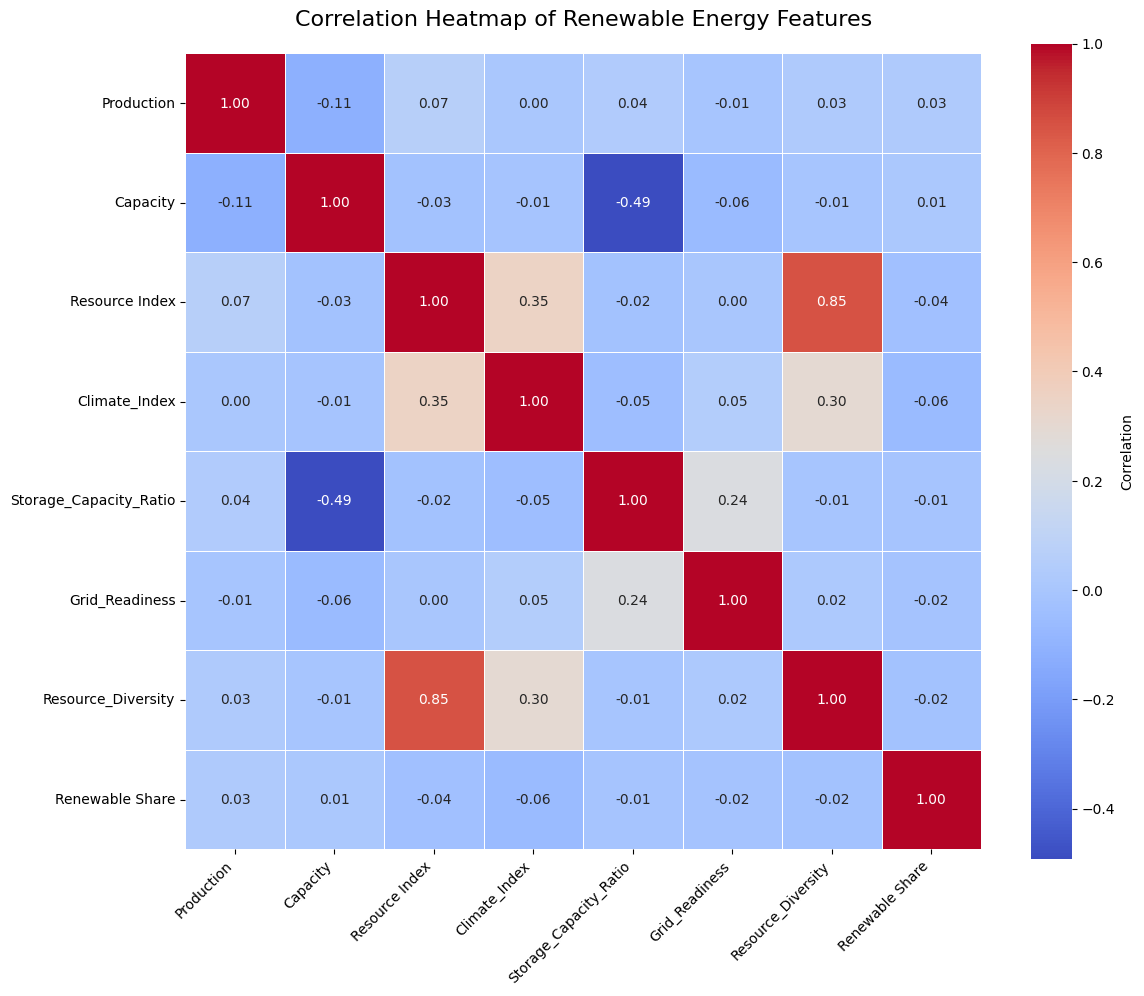

In [ ]:
corr_features = [
    'Production (GWh)',
    'Installed Capacity (MW)',
    'Renewable_Resource_Index',
    'Climate_Index',
    'Storage_Capacity_Ratio',
    'Grid_Readiness',
    'Resource_Diversity',
    'Proportion of Energy from Renewables'
]

corr_df = df_india[corr_features].copy()

corr_df.rename(columns={
    'Production (GWh)': 'Production',
    'Installed Capacity (MW)': 'Capacity',
    'Renewable_Resource_Index': 'Resource Index',
    'Climate_Suitability_Index': 'Climate Index',
    'Storage_to_Capacity_Ratio': 'Storage Ratio',
    'Grid_Readiness_Score': 'Grid Readiness',
    'Renewable_Resource_Diversity': 'Resource Diversity',
    'Proportion of Energy from Renewables': 'Renewable Share'
}, inplace=True)

corr_matrix = corr_df.corr(method='pearson')

plt.figure(figsize=(12,10))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    square=True,
    linewidths=0.5,
    cbar_kws={'label': 'Correlation'}
)

plt.title(
    'Correlation Heatmap of Renewable Energy Features',
    fontsize=16,
    pad=20
)

plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()

plt.show()

scatter plot

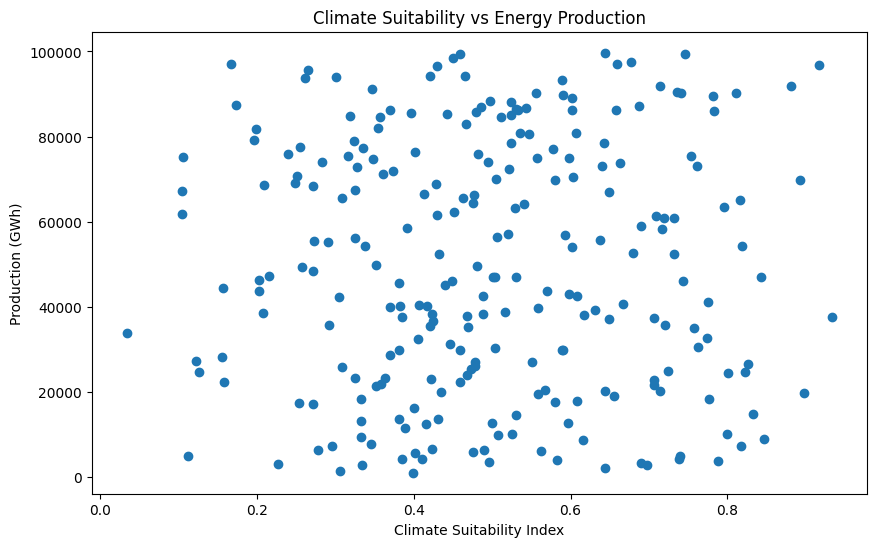

In [ ]:
plt.figure(figsize=(10,6))

plt.scatter(
    df_india['Climate_Index'],
    df_india['Production (GWh)']
)

plt.xlabel('Climate Suitability Index')
plt.ylabel('Production (GWh)')
plt.title('Climate Suitability vs Energy Production')
plt.show()

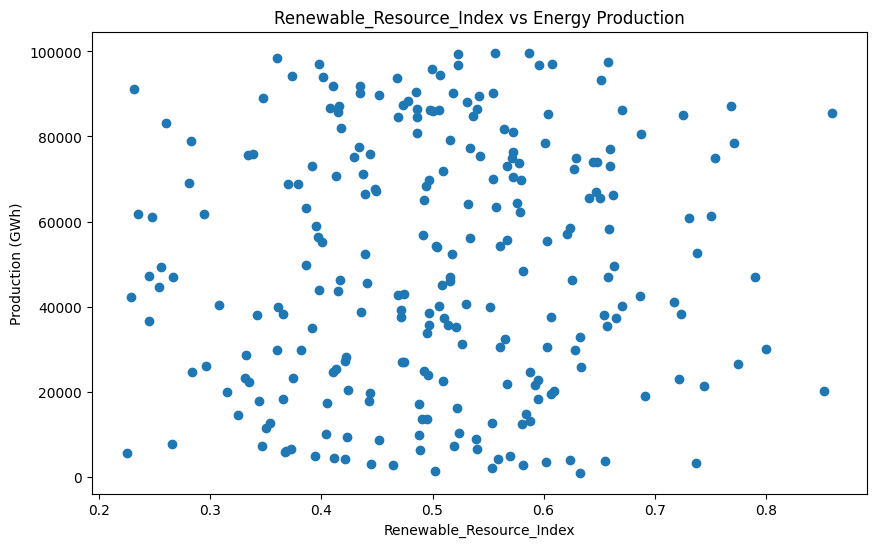

In [ ]:
plt.figure(figsize=(10,6))

plt.scatter(
    df_india['Renewable_Resource_Index'],
    df_india['Production (GWh)']
)

plt.xlabel('Renewable_Resource_Index')
plt.ylabel('Production (GWh)')
plt.title('Renewable_Resource_Index vs Energy Production')
plt.show()

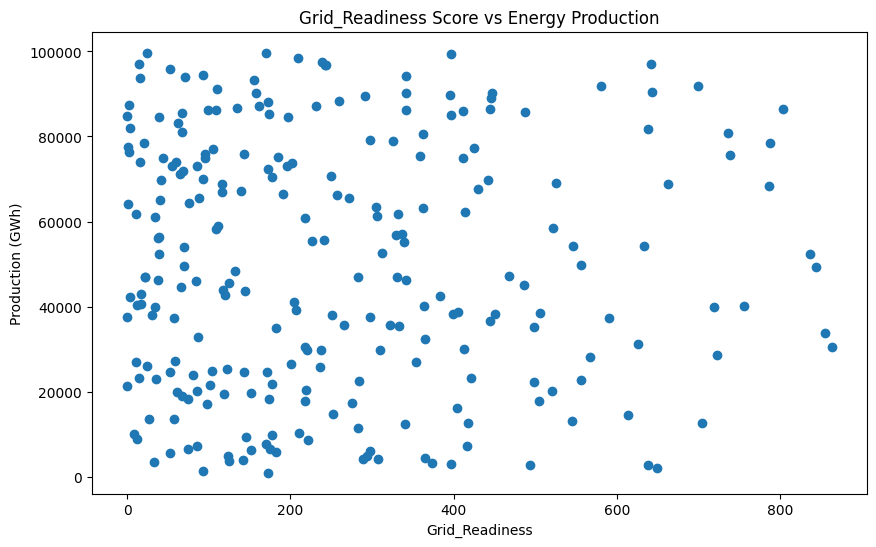

In [ ]:
plt.figure(figsize=(10,6))

plt.scatter(
    df_india['Grid_Readiness'],
    df_india['Production (GWh)']
)

plt.xlabel('Grid_Readiness')
plt.ylabel('Production (GWh)')
plt.title('Grid_Readiness Score vs Energy Production')
plt.show()

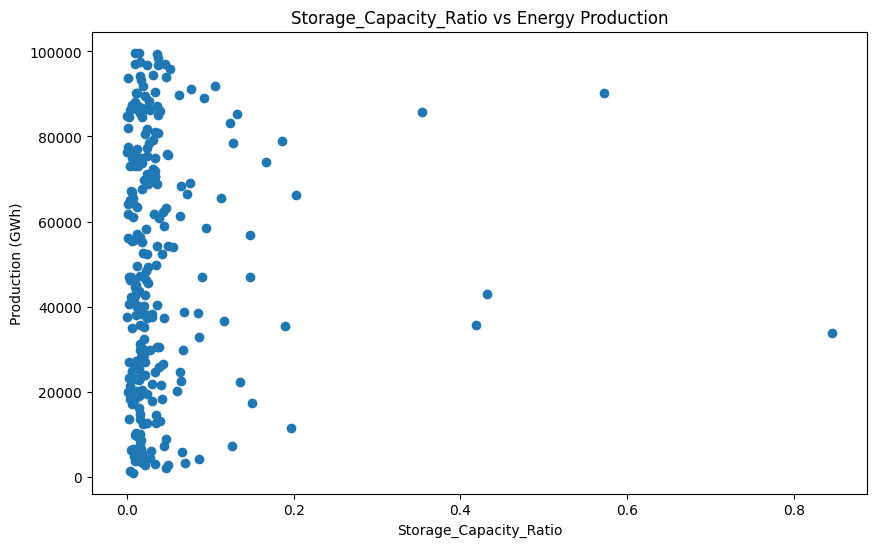

In [ ]:
plt.figure(figsize=(10,6))

plt.scatter(
    df_india['Storage_Capacity_Ratio'],
    df_india['Production (GWh)']
)

plt.xlabel('Storage_Capacity_Ratio')
plt.ylabel('Production (GWh)')
plt.title('Storage_Capacity_Ratio vs Energy Production')
plt.show()

**Time-Series Features**

Lag features are past values of a time series used to predict future values. They shift data backward in time so that a model can learn from historical patterns. For example, a lag of 1 uses the value from the immediately preceding time step to predict the current step

In [ ]:
Production_Lag = []
lag1 = df_india['Production (GWh)'].shift(1)
lag2 = df_india['Production (GWh)'].shift(2)
lag3 = df_india['Production (GWh)'].shift(3)
Production_Lag.append(lag1)
Production_Lag.append(lag2)
Production_Lag.append(lag3)
print("Production lag ", Production_Lag)

Production lag  [5                NaN
16      90483.647159
21      91946.614902
30       6542.685311
58      75015.109326
            ...     
2407    45651.390332
2441    61695.064648
2453    61853.106181
2466    67261.307756
2497    71809.968260
Name: Production (GWh), Length: 249, dtype: float64, 5                NaN
16               NaN
21      90483.647159
30      91946.614902
58       6542.685311
            ...     
2407    86681.453672
2441    45651.390332
2453    61695.064648
2466    61853.106181
2497    67261.307756
Name: Production (GWh), Length: 249, dtype: float64, 5                NaN
16               NaN
21               NaN
30      90483.647159
58      91946.614902
            ...     
2407     6056.648817
2441    86681.453672
2453    45651.390332
2466    61695.064648
2497    61853.106181
Name: Production (GWh), Length: 249, dtype: float64]


In [ ]:
#rolling mean
Rolling_Mean3Y = df_india['Production (GWh)'].rolling(window = 3).mean()
Rolling_Mean5Y = df_india['Production (GWh)'].rolling(window = 5).mean()
Rolling_Mean10Y = df_india['Production (GWh)'].rolling(window = 10).mean()
print("Rolling Mean 3Y ", Rolling_Mean3Y)
print("Rolling Mean 5Y ", Rolling_Mean5Y)
print("Rolling Mean 10Y ", Rolling_Mean10Y)

Rolling Mean 3Y  5                NaN
16               NaN
21      62990.982457
30      57834.803179
58      56037.782186
            ...     
2407    64675.969551
2441    56399.853720
2453    63603.159528
2466    66974.794066
2497    77800.288799
Name: Production (GWh), Length: 249, dtype: float64
Rolling Mean 5Y  5                NaN
16               NaN
21               NaN
30               NaN
58      70108.721724
            ...     
2407    41146.399643
2441    52387.532730
2453    64628.464518
2466    61654.167435
2497    71389.807445
Name: Production (GWh), Length: 249, dtype: float64
Rolling Mean 10Y  5                NaN
16               NaN
21               NaN
30               NaN
58               NaN
            ...     
2407    49104.267818
2441    51712.490606
2453    54642.139256
2466    51875.819753
2497    52563.408424
Name: Production (GWh), Length: 249, dtype: float64


In [ ]:
#Growth rate
Growth_Rate = df_india['Production (GWh)'].pct_change()
print(Growth_Rate)

5             NaN
16       0.016168
21      -0.928843
30      10.465492
58       0.153842
          ...    
2407     0.351439
2441     0.002562
2453     0.087436
2466     0.067627
2497     0.313600
Name: Production (GWh), Length: 249, dtype: float64


In [ ]:
#capacity growth
CapacityGrowth = df_india['Installed Capacity (MW)'].pct_change()
print(CapacityGrowth)

5            NaN
16      0.630958
21     -0.387412
30     -0.260119
58     -0.084205
          ...   
2407   -0.333207
2441    2.865096
2453   -0.063384
2466   -0.572787
2497    0.234054
Name: Installed Capacity (MW), Length: 249, dtype: float64


Prediction

Linear Regression

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import numpy as np

# Target variable
y = df_india['Production (GWh)']

# Feature variables
features = [
    'Installed Capacity (MW)',
    'Solar Irradiance',
    'Wind Speed',
    'Hydro Potential',
    'Geothermal Potential',
    'Biomass Availability',
    'Average Annual Temperature',
    'Annual Rainfall',
    'Energy Storage Capacity',
    'Grid Integration Capability',
    'CUF',
    'Renewable_Resource_Index',
    'Storage_Capacity_Ratio',
    'Grid_Readiness'
]

X = df_india[features]

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Standardization
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Linear Regression
lr = LinearRegression()

lr.fit(X_train_scaled, y_train)

# Prediction
pred_lr = lr.predict(X_test_scaled)

# Evaluation
mae = mean_absolute_error(y_test, pred_lr)
rmse = np.sqrt(mean_squared_error(y_test, pred_lr))
r2 = r2_score(y_test, pred_lr)

print("MAE :", mae)
print("RMSE:", rmse)
print("R²  :", r2)


# #MAE : 21749.414620420746
# RMSE: 29546.017725911257
# R²  : -0.0418236064814137

eroors are very large. this may be due to small dataset or non-linear relationship between features or very low correlation which needs to further investigated.


MAE : 21749.414620420746
RMSE: 29546.017725911257
R²  : -0.0418236064814137


Random Forest
For Random Forest Regression, you do not need StandardScaler because decision trees are not affected by feature scaling.

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Target
y = df_india['Production (GWh)']

# Features
features = [
    'Installed Capacity (MW)',
    'Solar Irradiance',
    'Wind Speed',
    'Hydro Potential',
    'Geothermal Potential',
    'Biomass Availability',
    'Average Annual Temperature',
    'Annual Rainfall',
    'Energy Storage Capacity',
    'Grid Integration Capability',
    'CUF',
    'Renewable_Resource_Index',
    'Storage_Capacity_Ratio',
    'Grid_Readiness'
]

X = df_india[features]

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Random Forest Model
rf = RandomForestRegressor(
    n_estimators=500,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

# Prediction
pred_rf = rf.predict(X_test)

# Evaluation
mae_rf = mean_absolute_error(y_test, pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, pred_rf))
r2_rf = r2_score(y_test, pred_rf)

print("MAE :", mae_rf)
print("RMSE:", rmse_rf)
print("R²  :", r2_rf)

MAE : 7533.20937593907
RMSE: 10852.391568253754
R²  : 0.8594447097659066


Comparison between Linear Regression and Random Forest

Model                    MAE       RMSE       R^2  

Linear Regression  21,749.41  29,546.02  0.0418

Random Forest       7,533.21  10,852.39   0.8594


Linear Regression : R^2 = 0.0418 -> This implies that the model explains less than 0% of the variation in renewable energy production.

Random Forest: R^2 = 0.8594 -> Random Forest explains approximately 85.94% of the variation in renewable energy production.

MAE Improvement:

((21749.41 - 7533.21) / 21749.41) * 100 = 65.4% reduction

RMSE Improvement:

((29546.02 - 10852.39) / 29546.02) * 100 = 63.3% reduction

Conclusion:

Random Forest outperform Linear Regression.


ARIMA

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

df_arima = df_india.sort_values('Year')
ts = df_arima['Production (GWh)']
train_size = int(len(ts) * 0.8)
train = ts[:train_size]
test = ts[train_size:]
model = ARIMA(train, order=(1,1,1))
model_fit = model.fit()
forecast = model_fit.forecast(steps=len(test))
mae = mean_absolute_error(test, forecast)
rmse = np.sqrt(mean_squared_error(test, forecast))
r2 = r2_score(test, forecast)

print("MAE :", mae)
print("RMSE:", rmse)
print("R²  :", r2)



MAE : 28900.46327306058
RMSE: 32103.61880196912
R²  : -0.021261990790095053


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be give

ARIMA Result Interpretation

MAE and RMSE are the worst among the three models.
R^2 is negative.

So, ARIMA performs worse than simply predicting the mean production value.